In [67]:
import numpy as np
rng = np.random.default_rng(42)

In [68]:
n = 200; x = rng.uniform(-1.0,1.0,size=n)
x.min(), x.max(), x.mean()

(np.float64(-0.985275460497989),
 np.float64(0.9847511281116741),
 np.float64(-0.01226089132740848))

In [69]:
a_true = 0.7; b_true= -1.3
noise_std = 0.15
eps = rng.normal(0.0, noise_std, size=n)

In [70]:
y = a_true+b_true*x + eps
list(zip(x[:5],y[:5]))

[(np.float64(0.5479120971119267), np.float64(0.08421329295785193)),
 (np.float64(-0.12224312049589536), np.float64(0.7997252882157255)),
 (np.float64(0.7171958398227649), np.float64(-0.23312287177760518)),
 (np.float64(0.3947360581187278), np.float64(0.1623266896669769)),
 (np.float64(-0.8116453042247009), np.float64(1.8057750778119512))]

In [71]:
idx = rng.permutation(n)
val_frac = 0.2
n_val = int(n*val_frac)
val_idx, train_idx = idx[:n_val], idx[n_val:]

In [72]:
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

In [73]:
x_train.shape, x_val.shape

((160,), (40,))

In [74]:
def Predict(phi0,phi1,x):
    x = np.asarray(x).reshape(-1,1) #(n,1)
    X = np.column_stack([np.ones((x.shape[0],1)), x]) #(n,2)
    beta = np.array([[phi0],[phi1]]) #(2,1)
    y_hat = X @ beta #(n,1)
    return y_hat

In [75]:
def Loss(y_hat, y):
    y = np.asarray(y).reshape(-1,1) #(n,1)
    e = y_hat - y
    return e, np.mean(e**2)

In [76]:
def Gradient(e,x):
    x = np.asarray(x).reshape(-1,1) #(n,1)
    L_phi0 = 2*np.mean(e)
    L_phi1 = 2*np.mean(x*e)
    return L_phi0, L_phi1

In [77]:
def Step(phi0,phi1,x_train,y_train,lr):
    y_hat = Predict(phi0,phi1,x_train)
    e, loss = Loss(y_hat,y_train)
    L_phi0, L_phi1 = Gradient(e,x_train)
    phi0 -= lr*L_phi0
    phi1 -= lr*L_phi1

    
    return phi0, phi1, loss , L_phi0, L_phi1

In [84]:
phi0 = 0; phi1 = 0
for count in range(500):
    phi0,phi1,loss,L_phi0,L_phi1 = Step(phi0,phi1,x_train,y_train,0.2)
    norm = np.sqrt(L_phi0**2 + L_phi1**2)
    if (count % 50 == 0):
        print(loss)
    if norm < 1e-6:
        print(f"Convergent at {count}")
        break


1.0404151593085693
0.024288311802621705
0.024287742806228734
Convergent at 100


In [89]:
import matplotlib.pyplot as plt

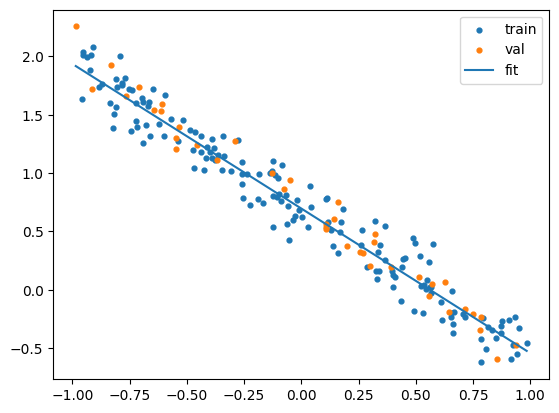

<Figure size 640x480 with 0 Axes>

In [93]:
x_line = np.linspace(min(x_train.min(),x_val.min()),
                    max(x_train.max(),x_val.max()),
                    200)
y_line = phi0 + phi1*x_line
fig,ax = plt.subplots()
plt.figure()
ax.scatter(x_train,y_train,s=12, label="train")
ax.scatter(x_val,y_val,s=12,label="val")
ax.plot(x_line,y_line,label="fit")
ax.legend()
plt.show()

In [ ]:
y_hat_val = phi0+phi1*x_val
loss_val = Loss(y_hat_val,y_val)